In [1]:
%pip install numpy scipy matplotlib scikit-learn umap-learn h5py

import numpy as np
import scipy
import sklearn
import umap
import matplotlib.pyplot as plt
import os

print("✅ Packages installed successfully.")


✅ Packages installed successfully.


In [2]:
#查看包版本
import scipy.io as sio
from scipy.io import loadmat


print("NumPy version:", np.__version__)
print("SciPy version:", scipy.__version__)
print("Scikit-learn version:", sklearn.__version__)
print("UMAP imported successfully")

NumPy version: 1.21.5
SciPy version: 1.7.3
Scikit-learn version: 1.0.2
UMAP imported successfully


In [3]:
#色阶
from matplotlib.colors import LinearSegmentedColormap

# BrainRegionStaining 风格
brain_colors = [
    (0.00, (0.00, 0.00, 0.00)),   # black
    (0.10, (0.00, 0.00, 0.50)),   # dark blue
    (0.20, (0.00, 0.20, 0.65)),   # deep blue
    (0.30, (0.00, 0.40, 0.80)),   # blue
    (0.40, (0.00, 0.60, 0.90)),   # light blue
    (0.50, (0.00, 0.80, 0.90)),   # cyan-blue
    (0.60, (0.30, 0.60, 0.90)),   # periwinkle
    (0.70, (0.60, 0.40, 0.95)),   # purple
    (0.80, (0.85, 0.30, 0.85)),   # magenta
    (0.90, (1.00, 0.50, 0.75)),   # pink
    (1.00, (1.00, 1.00, 1.00)),   # white
]

brain_cmap = LinearSegmentedColormap.from_list("BrainRegionStaining", brain_colors, N=256)

icolors = [
    (0.00, (0.00, 0.00, 0.00)),   # black
    (0.08, (0.02, 0.04, 0.12)),   # blue black
    (0.18, (0.00, 0.18, 0.45)),   # navy blue
    (0.30, (0.00, 0.50, 0.85)),   # blue cyan
    (0.42, (0.00, 0.85, 0.75)),   # teal
    (0.54, (0.35, 0.95, 0.45)),   # green
    (0.66, (0.65, 0.55, 1.00)),   # soft violet
    (0.78, (0.95, 0.35, 0.85)),   # magenta
    (0.90, (1.00, 0.70, 0.30)),   # orange gold
    (1.00, (1.00, 1.00, 1.00)),   # white
]

icmap = LinearSegmentedColormap.from_list(
    "Balanced_Jump_BlackToWhite",
    icolors,
    N=256
)

In [4]:
# Raman x轴 mat 文件
X_AXIS_PATH = "H:/拉曼-实习/肺癌/xhoriba1134.mat"    #記得改地址

# 读取
axis_mat = loadmat(X_AXIS_PATH)

# 查看变量
print("Variables in x-axis MAT:")

for key, value in axis_mat.items():
    if not key.startswith("__"):
        print(key, type(value), getattr(value, "shape", None))

Variables in x-axis MAT:
xHoriba <class 'numpy.ndarray'> (1, 1134)


In [5]:
raman_axis = axis_mat["xHoriba"]

# 从 (1, 1134) 转换为 (1134,)
raman_axis = np.squeeze(raman_axis)

print("Raman axis shape:", raman_axis.shape)

print("\nFirst 10 Raman shifts:")
print(raman_axis[:10])

Raman axis shape: (1134,)

First 10 Raman shifts:
[ 0.810777  5.09344   9.37415  13.6529   17.9297   22.2046   26.4797
 30.7506   35.0197   39.2868  ]


## HERE

In [94]:
MAT_PATH = "H:\拉曼-实习\肺癌/LungCancerImageRaw2/Solid_layer14.mat"
output_dir = r"H:\拉曼-实习\肺癌/Solid/Solid_layer14"
layer=14
# 目标尺寸
output_width = 210
output_height = 210
# 当前 layer 的图像尺寸
# 请根据你的实际数据修改
image_width = 210
image_height = 210
mat = loadmat(MAT_PATH)

n_rows=210
n_cols=210
print("Variables in Raman MAT:")

for key, value in mat.items():

    if not key.startswith("__"):

        if isinstance(value, np.ndarray):

            print(
                key,
                value.shape,
                value.dtype
            )

Variables in Raman MAT:
data_struct (1, 1) [('name', 'O'), ('data', 'O'), ('axisscale', 'O'), ('imagesize', 'O'), ('imagedimension_um', 'O')]


In [95]:
ds = mat["data_struct"]

print("data_struct type:", type(ds))
print("data_struct shape:", ds.shape)
print("data_struct fields:", ds.dtype.names)

data_struct type: <class 'numpy.ndarray'>
data_struct shape: (1, 1)
data_struct fields: ('name', 'data', 'axisscale', 'imagesize', 'imagedimension_um')


In [96]:
X = ds["data"][0, 0]

print("X type:", type(X))
print("X shape:", X.shape)

X type: <class 'numpy.ndarray'>
X shape: (44100, 1134)


In [97]:
from scipy.io import loadmat, savemat
from sklearn.linear_model import LinearRegression


# ============================================================
# 1. 参数
# ============================================================

reference_mat_path = (
    r"H:\拉曼-实习\肺癌/Solid/endmembers_matrix.mat"
)



os.makedirs(output_dir, exist_ok=True)


In [98]:
reference_mat = loadmat(reference_mat_path)

print("MAT 文件中的变量：")

for key, value in reference_mat.items():
    if not key.startswith("__"):
        print(
            f"{key}:",
            getattr(value, "shape", "not ndarray")
        )
# 自动寻找二维数值矩阵
candidate_arrays = {
    key: np.asarray(value)
    for key, value in reference_mat.items()
    if (
        not key.startswith("__")
        and isinstance(value, np.ndarray)
        and value.ndim == 2
        and np.issubdtype(value.dtype, np.number)
    )
}

if len(candidate_arrays) == 0:
    raise ValueError(
        "MAT 文件中没有找到二维数值矩阵。"
    )


# 优先寻找形状为 (60, 1114) 或 (1114, 60) 的矩阵
H_reference = None
reference_key = None

for key, value in candidate_arrays.items():

    if value.shape == (60, 1134):
        H_reference = value
        reference_key = key
        break

if H_reference is None:
    raise ValueError(
        "没有找到形状为 (60, 1114) 或 "
        "(1114, 60) 的参考光谱矩阵。\n"
        f"目前找到的二维矩阵为："
        f"{[(k, v.shape) for k, v in candidate_arrays.items()]}"
    )


H_reference = np.asarray(
    H_reference,
    dtype=np.float64
)

print("\n使用的参考光谱变量：", reference_key)
print("参考光谱矩阵 H_reference：", H_reference.shape)


MAT 文件中的变量：
endmembers: (60, 1134)

使用的参考光谱变量： endmembers
参考光谱矩阵 H_reference： (60, 1134)


In [99]:
# 3. 检查 X
# ============================================================

X = np.asarray(
    X,
    dtype=np.float64
)
n_pixels, n_bands = X.shape
n_components, reference_bands = H_reference.shape

print("待解谱数据 X：", X.shape)
print("参考光谱数量：", n_components)
print("光谱点数量：", n_bands)


待解谱数据 X： (44100, 1134)
参考光谱数量： 60
光谱点数量： 1134


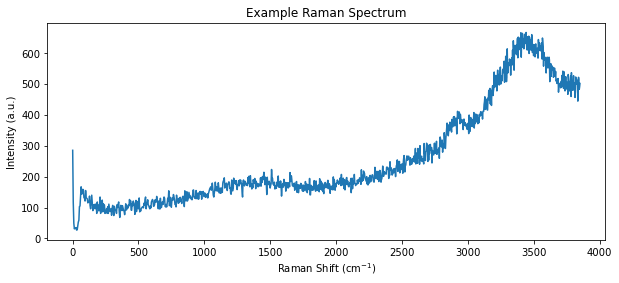

In [100]:
plt.figure(figsize=(10, 4))

plt.plot(
    raman_axis,
    X[0]
)

plt.xlabel("Raman Shift (cm$^{-1}$)")
plt.ylabel("Intensity (a.u.)")
plt.title("Example Raman Spectrum")

plt.show()

In [101]:
# 去掉 nan / inf
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

# 每条光谱减去最小值
X_pre = X - X.min(axis=1, keepdims=True)

# 每条光谱归一化到最大值 = 1
X_pre = X_pre / (X_pre.max(axis=1, keepdims=True) + 1e-12)

print("X_pre shape:", X_pre.shape)


H_nonnegative = np.maximum(H_reference, 0)

X_pre shape: (44100, 1134)


In [102]:
# 5. 参考光谱归一化
# ============================================================

# 必须记录每条参考光谱的缩放量。
# 解谱完成后要把系数换算回原始参考光谱对应的系数。

reference_norm = np.linalg.norm(
    H_nonnegative,
    axis=1
)

reference_norm[
    reference_norm < 1e-12
] = 1.0

H_fit = (
    H_nonnegative
    / reference_norm[:, None]
)

print("归一化后的参考矩阵：", H_fit.shape)


归一化后的参考矩阵： (60, 1134)


In [103]:
# 6. 使用非负线性回归进行批量 NNLS 解谱
# ============================================================

# 对每个像素：
#
# X[pixel, :] ≈ abundance[pixel, :] @ H_reference
#
# sklearn 中：
# H_fit.T              -> (1114, 60)
# X_nonnegative.T      -> (1114, n_pixels)
# abundance_normalized -> (n_pixels, 60)

nnls_model = LinearRegression(
    positive=True,
    fit_intercept=False,
    n_jobs=-1
)

print("\n开始 NNLS 解谱……")

nnls_model.fit(
    H_fit.T,
    X_pre.T
)

A_normalized = nnls_model.coef_

print(
    "NNLS 输出系数形状：",
    A_normalized.shape
)


# 换算为相对于原始参考光谱 H_reference 的系数
A_abundance = (
    A_normalized
    / reference_norm[None, :]
)

print(
    "最终 abundance 矩阵：",
    A_abundance.shape
)


开始 NNLS 解谱……
NNLS 输出系数形状： (44100, 60)
最终 abundance 矩阵： (44100, 60)


In [104]:
# 7. 光谱重建和残差
# ============================================================

X_reconstructed = (
    A_abundance
    @ H_nonnegative
)

residual = (
    X_pre
    - X_reconstructed
)

residual_norm = np.linalg.norm(
    residual,
    axis=1
)

original_norm = np.linalg.norm(
    X_pre,
    axis=1
)

relative_residual = (
    residual_norm
    / np.maximum(original_norm, 1e-12)
)

explained_fraction = (
    1.0
    - relative_residual
)

explained_fraction = np.clip(
    explained_fraction,
    0,
    1
)

print("\n平均相对残差：", relative_residual.mean())
print("相对残差中位数：", np.median(relative_residual))
print("平均拟合比例：", explained_fraction.mean())


平均相对残差： 0.15936346768123189
相对残差中位数： 0.16221919178332145
平均拟合比例： 0.840636532318768


In [105]:
# 8. 可选：计算每个像素内各成分的相对比例
# ============================================================

abundance_sum = np.sum(
    A_abundance,
    axis=1,
    keepdims=True
)

A_fraction = (
    A_abundance
    / np.maximum(abundance_sum, 1e-12)
)

# A_abundance：绝对 NNLS 系数
# A_fraction：每个像素内60个系数归一化后的相对比例

abundance_sum = np.sum(
    A_abundance,
    axis=1,
    keepdims=True
)


abundance_relative = np.divide(
    A_abundance,
    abundance_sum,
    out=np.zeros_like(A_abundance),
    where=abundance_sum > 1e-12
)


print(
    "abundance_relative shape:",
    abundance_relative.shape
)

abundance_relative shape: (44100, 60)


In [106]:
# 9. 映射回原始图像
# ============================================================

# 根据你之前 151*155 的数据：
# 如果像素顺序是先扫描 x，再扫描 y，通常先恢复为
# (height, width)，即 (155, 151)。

abundance_maps = A_abundance.reshape(
    image_height,
    image_width,
    n_components
)


fraction_maps = abundance_relative.reshape(
    image_height,
    image_width,
    n_components
)

residual_map = relative_residual.reshape(
    image_height,
    image_width
)

fit_map = explained_fraction.reshape(
    image_height,
    image_width
)

print(
    "\nabundance maps：",
    abundance_maps.shape
)




abundance maps： (210, 210, 60)


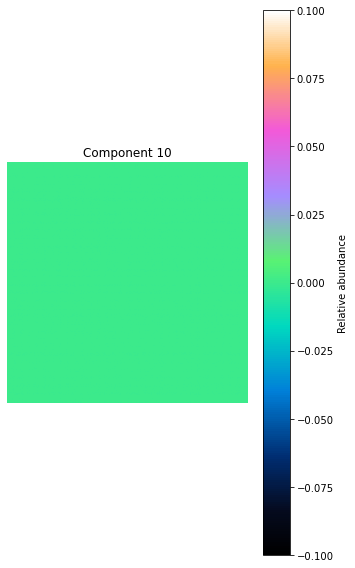

In [107]:
import matplotlib.pyplot as plt


k = 10


component_map = abundance_relative[
    :,
    k
].reshape(
    (n_rows, n_cols),
    order="F"
)


plt.figure(
    figsize=(5, 8)
)

plt.imshow(
    component_map,
    cmap=icmap,
    origin="upper"
)

plt.colorbar(
    label="Relative abundance"
)

plt.title(
    f"Component {k}"
)

plt.axis("off")

plt.tight_layout()
plt.show()

In [108]:
n_clusters = 60

fig, axes = plt.subplots(
    10, 10,
    figsize=(20, 20)
)

axes = axes.ravel()

for k in range(n_clusters):

    binary_map = (cluster_map == k).astype(float)

    axes[k].imshow(
        binary_map,
        origin="lower",
        cmap="gray"
    )

    axes[k].set_title(
        f"Cluster {k}",
        fontsize=8
    )

    axes[k].axis("off")

plt.tight_layout()
plt.show()

(44100,)
(210, 210)


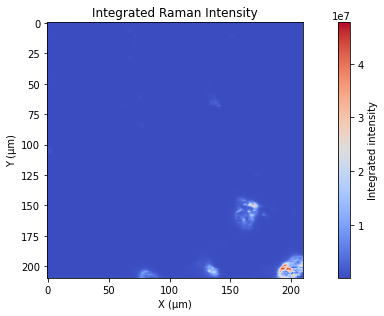

In [109]:
total_intensity = np.sum(X, axis=1)



print(total_intensity.shape)
raw_map = total_intensity.reshape(
    n_cols,
    n_rows
)

print(raw_map.shape)
plt.figure(figsize=(10, 4.5))

plt.imshow(
    raw_map,
    cmap="coolwarm",
    origin="upper",

    aspect="equal"
)

plt.xlabel("X (µm)")
plt.ylabel("Y (µm)")
plt.title("Integrated Raman Intensity")

plt.colorbar(
    label="Integrated intensity"
)

plt.tight_layout()
plt.show()

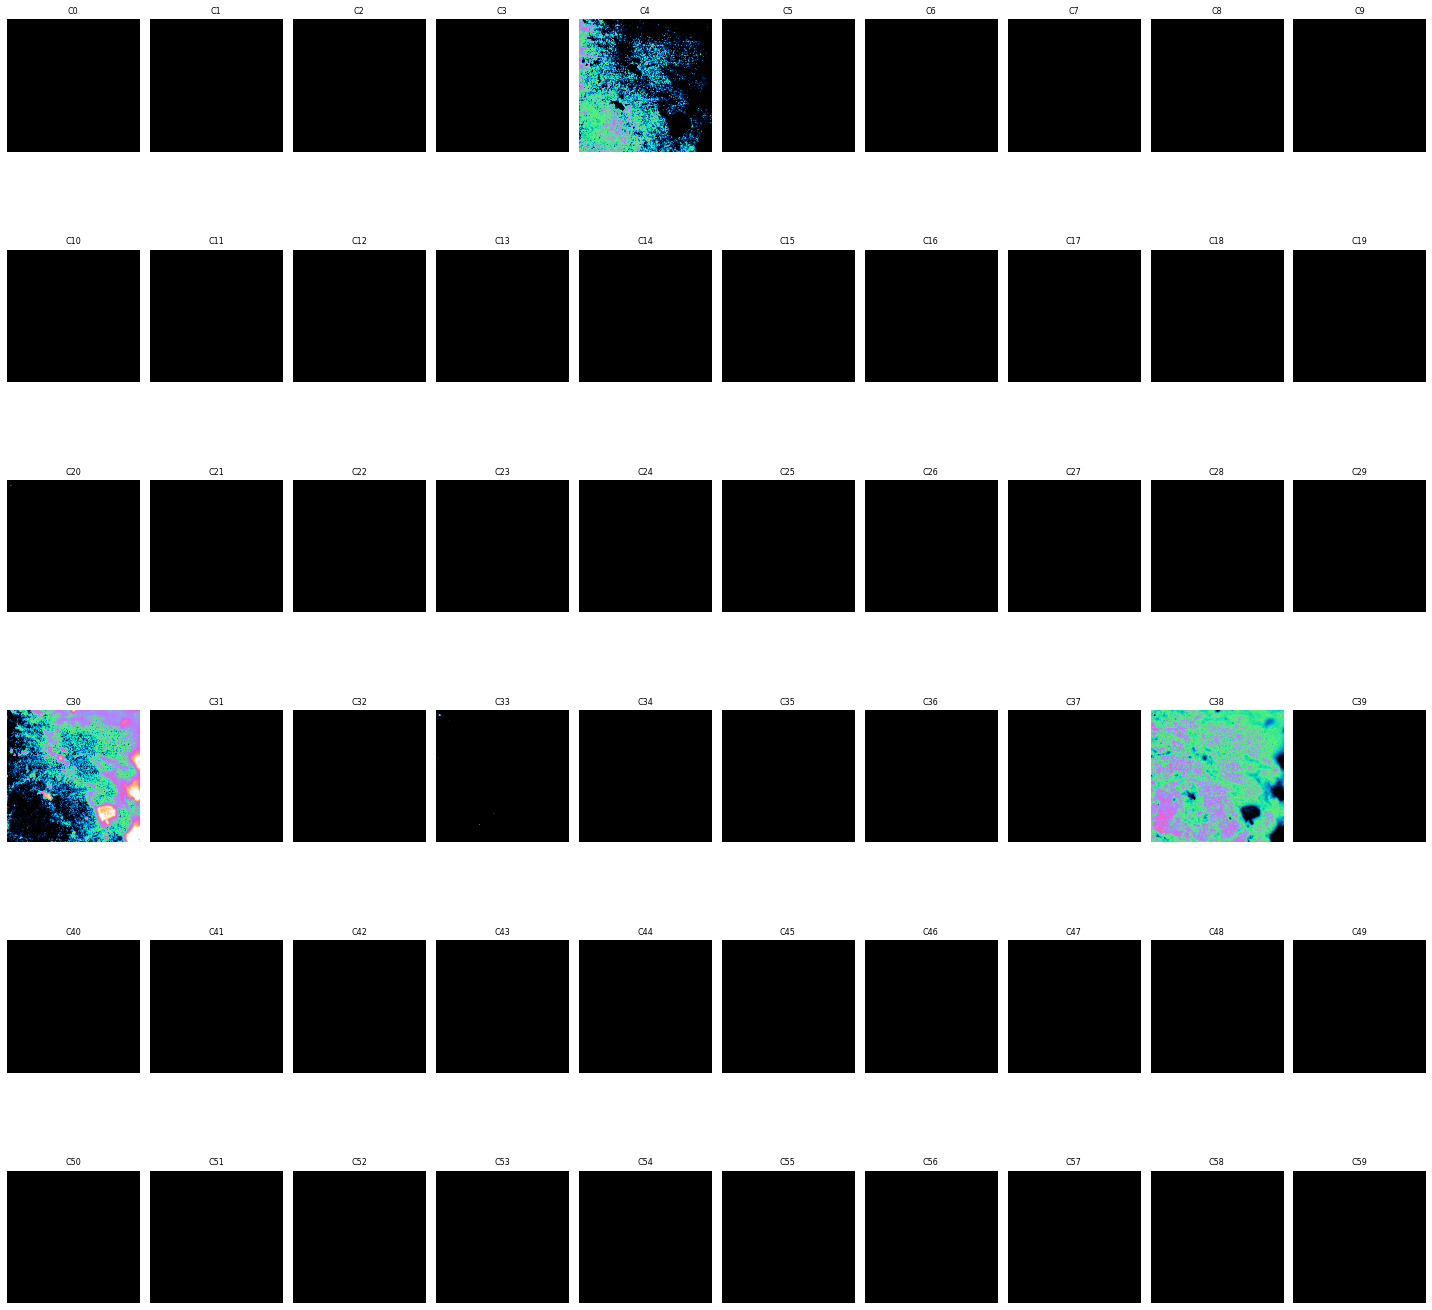

In [110]:
fig, axes = plt.subplots(
    6,
    10,
    figsize=(20, 20)
)

axes = axes.ravel()


for k in range(n_components):

    # 单独取出第k个component在所有pixel中的abundance
    component_abundance = abundance_relative[
        :,
        k
    ]


    # 恢复成完整空间图
    component_map = component_abundance.reshape(
        (n_rows, n_cols),
        order="F"
    )


    axes[k].imshow(
        component_map,
        cmap=icmap,
        origin="upper"
    )


    axes[k].set_title(
        f"C{k}",
        fontsize=8
    )

    axes[k].axis("off")


plt.tight_layout()
plt.show()


In [111]:
#每张图输出，不进行全局colorbar

# ========= 参数 =========
n_components = 60
reshape_order = "F"   # 如果你最后确认不是F，就改成正确的




In [112]:
abundance_maps = np.zeros(
    (
        n_rows,
        n_cols,
        n_components
    ),
    dtype=np.float64
)


for component_idx in range(n_components):

    abundance_maps[
        :,
        :,
        component_idx
    ] = abundance_relative[
        :,
        component_idx
    ].reshape(
        (n_rows, n_cols),
        order=reshape_order
    )


print(
    "abundance_maps shape:",
    abundance_maps.shape
)

abundance_maps shape: (210, 210, 60)


In [113]:
import gc
import tifffile

from scipy.ndimage import zoom
for variable_name in [
    "X_reconstructed",
    "residual",
    "H_fit",
    "X_nonnegative"
]:

    if variable_name in globals():
        del globals()[variable_name]


gc.collect()

print("已释放不需要的大型中间变量")

已释放不需要的大型中间变量


In [114]:
# ============================================================
# 低内存保存60张灰度TIFF abundance map
# ============================================================

save_dir = os.path.join(
    output_dir,
    "grayscale_abundance_maps"
)

os.makedirs(
    save_dir,
    exist_ok=True
)





# 统一灰度范围
global_max = float(
    np.nanmax(abundance_maps)
)

if not np.isfinite(global_max) or global_max <= 0:

    raise ValueError(
        "abundance_maps中没有有效的正数。"
    )


for component_idx in range(n_components):

    print(
        f"正在保存 "
        f"{component_idx + 1}/{n_components}"
    )


    # 只提取当前一张图
    current_map = np.asarray(
        abundance_maps[
            :,
            :,
            component_idx
        ],
        dtype=np.float32
    )


    # 替换NaN和Inf
    current_map = np.nan_to_num(
        current_map,
        nan=0.0,
        posinf=global_max,
        neginf=0.0,
        copy=False
    )


    # 计算缩放比例
    zoom_y = (
        output_height
        / current_map.shape[0]
    )

    zoom_x = (
        output_width
        / current_map.shape[1]
    )


    # 双线性插值到接近目标大小
    resized_map = zoom(
        current_map,
        zoom=(
            zoom_y,
            zoom_x
        ),
        order=1,
        prefilter=False
    )


    # 防止浮点取整造成尺寸差1个像素
    resized_map = resized_map[
        :output_height,
        :output_width
    ]


    # 如果尺寸仍不足，补0
    pad_height = max(
        0,
        output_height - resized_map.shape[0]
    )

    pad_width = max(
        0,
        output_width - resized_map.shape[1]
    )

    if pad_height > 0 or pad_width > 0:

        resized_map = np.pad(
            resized_map,
            (
                (0, pad_height),
                (0, pad_width)
            ),
            mode="constant",
            constant_values=0
        )


    # 统一转换为16-bit灰度
    grayscale_map = (
        np.clip(
            resized_map,
            0,
            global_max
        )
        / global_max
        * 65535.0
    ).astype(
        np.uint16
    )


    save_path = os.path.join(
        save_dir,
        f"component_{component_idx:02d}_abundance_layer{layer}.tiff"
    )


    # 不压缩，减少内存和编码负担
    tifffile.imwrite(save_path,grayscale_map, photometric="minisblack", compression=None,metadata=None)


    # 主动释放当前图片
    del current_map
    del resized_map
    del grayscale_map


    gc.collect()


print("保存完成：", save_dir)

正在保存 1/60
正在保存 2/60
正在保存 3/60
正在保存 4/60
正在保存 5/60
正在保存 6/60
正在保存 7/60
正在保存 8/60
正在保存 9/60
正在保存 10/60
正在保存 11/60
正在保存 12/60
正在保存 13/60
正在保存 14/60
正在保存 15/60
正在保存 16/60
正在保存 17/60
正在保存 18/60
正在保存 19/60
正在保存 20/60
正在保存 21/60
正在保存 22/60
正在保存 23/60
正在保存 24/60
正在保存 25/60
正在保存 26/60
正在保存 27/60
正在保存 28/60
正在保存 29/60
正在保存 30/60
正在保存 31/60
正在保存 32/60
正在保存 33/60
正在保存 34/60
正在保存 35/60
正在保存 36/60
正在保存 37/60
正在保存 38/60
正在保存 39/60
正在保存 40/60
正在保存 41/60
正在保存 42/60
正在保存 43/60
正在保存 44/60
正在保存 45/60
正在保存 46/60
正在保存 47/60
正在保存 48/60
正在保存 49/60
正在保存 50/60
正在保存 51/60
正在保存 52/60
正在保存 53/60
正在保存 54/60
正在保存 55/60
正在保存 56/60
正在保存 57/60
正在保存 58/60
正在保存 59/60
正在保存 60/60
保存完成： H:\拉曼-实习\肺癌/Solid/Solid_layer14\grayscale_abundance_maps


In [115]:
import os
import gc
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image


absolute_map_dir = os.path.join(
    output_dir,
    "absolute_abundance_maps"
)

os.makedirs(
    absolute_map_dir,
    exist_ok=True
)


# 直接从A_abundance确定component数量
n_components_to_save = A_abundance.shape[1]


# 所有component统一使用相同色阶范围
global_max = float(
    np.nanmax(A_abundance)
)

if not np.isfinite(global_max) or global_max <= 0:

    raise ValueError(
        "A_abundance中没有有效的正数。"
    )


# icmap既可以是字符串，也可以是已经定义好的colormap
if isinstance(icmap, str):

    cmap_object = plt.get_cmap(
        icmap
    )

else:

    cmap_object = icmap


saved_count = 0


for component_idx in range(n_components_to_save):

    # 取出当前component的绝对abundance
    component_abundance = A_abundance[
        :,
        component_idx
    ]


    # 按照正确的空间方向恢复图像
    current_map = component_abundance.reshape(
        (n_rows, n_cols),
        order="F"
    ).astype(
        np.float32
    )


    # 处理NaN和Inf
    current_map = np.nan_to_num(
        current_map,
        nan=0.0,
        posinf=global_max,
        neginf=0.0
    )
# 应用icmap，得到彩色图
    rgba_image = cmap_object(
        current_map,
        bytes=True
    )
    rgb_image = rgba_image[:, :, :3]

    output_image = Image.fromarray(
        rgb_image,
        mode="RGB"
    )

    output_image = output_image.resize(
        (output_width, output_height),
        resample=Image.BILINEAR
    )

    save_path = os.path.join(
        absolute_map_dir,
        f"component_{component_idx:02d}_abundance_layer{layer}.tiff"
    )

    # 只保存一次：彩色RGB TIFF
    output_image.save(
        save_path,
        format="TIFF",
        compression="raw"
    )

    if not os.path.isfile(save_path):
        raise RuntimeError(f"图片保存失败：{save_path}")

    saved_count += 1
    print(
        f"已保存 {saved_count}/{n_components_to_save}: "
        f"{os.path.basename(save_path)}"
    )

    output_image.close()
    del component_abundance
    del current_map
    #del normalized_map
    del rgba_image
    del rgb_image
    del output_image
    
# 关闭当前内核中所有Matplotlib图片
plt.close("all")

# 垃圾回收
gc.collect()


print("\n保存完成。")

已保存 1/60: component_00_abundance_layer14.tiff
已保存 2/60: component_01_abundance_layer14.tiff
已保存 3/60: component_02_abundance_layer14.tiff
已保存 4/60: component_03_abundance_layer14.tiff
已保存 5/60: component_04_abundance_layer14.tiff
已保存 6/60: component_05_abundance_layer14.tiff
已保存 7/60: component_06_abundance_layer14.tiff
已保存 8/60: component_07_abundance_layer14.tiff
已保存 9/60: component_08_abundance_layer14.tiff
已保存 10/60: component_09_abundance_layer14.tiff
已保存 11/60: component_10_abundance_layer14.tiff
已保存 12/60: component_11_abundance_layer14.tiff
已保存 13/60: component_12_abundance_layer14.tiff
已保存 14/60: component_13_abundance_layer14.tiff
已保存 15/60: component_14_abundance_layer14.tiff
已保存 16/60: component_15_abundance_layer14.tiff
已保存 17/60: component_16_abundance_layer14.tiff
已保存 18/60: component_17_abundance_layer14.tiff
已保存 19/60: component_18_abundance_layer14.tiff
已保存 20/60: component_19_abundance_layer14.tiff
已保存 21/60: component_20_abundance_layer14.tiff
已保存 22/60: component_2

In [116]:
import glob


print("当前工作目录：")
print(os.getcwd())

print("\nsave_dir原始值：")
print(save_dir)

print("\n文件夹中的文件数量：")
print(len(os.listdir(save_dir)))




当前工作目录：
D:\Jupyter\Raman

save_dir原始值：
H:\拉曼-实习\肺癌/Solid/Solid_layer14\grayscale_abundance_maps

文件夹中的文件数量：
60
